### CardioRisk ML
#### Preprocessing & Feature Engineering

In this notebook I transform the raw dataset into a format suitable for machine learning.

The preprocessing pipeline covers five main stages:

1. **Categorical encoding**, ordinal variables preserve their clinically meaningful order,
   nominal variables are one-hot encoded to avoid spurious numeric distances.
2. **Feature engineering**, eight derived clinical indices are created from existing
   variables, capturing synergistic effects that linear models cannot detect in isolation.
3. **Stratified train/test split**, 80/20 split that preserves the target class ratio
   in both partitions.
4. **Scaling**, StandardScaler fitted exclusively on the training set to prevent
   data leakage into the test set.
5. **Class balancing**, SMOTE applied only to the training set, leaving the test set
   at its natural distribution for unbiased evaluation.

In [1]:
"""
Environment setup.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing   import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling  import SMOTE

# Paths 
RAW_DIR       = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR   = Path("../data/eda_charts")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Constants
RANDOM_STATE = 42

# Colour palette
COLOR_LOW  = "#2ECC71"
COLOR_HIGH = "#E74C3C"

# Plot defaults 
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

pd.set_option("display.max_columns", None)


def save_plot(name: str) -> None:
    plt.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

#### Data Loading

In [2]:
"""
I remove the ID column at this point because it carries no predictive
signal and would otherwise need to be excluded from every subsequent
operation manually.
"""

df_raw = pd.read_csv(RAW_DIR / "cardiovascular_patients.csv")
df     = df_raw.drop(columns=["patient_id"]).copy()

print(f"Shape after dropping ID: {df.shape}")
print(f"Target balance: {df['cardiovascular_risk'].mean() * 100:.1f}% high risk")

Shape after dropping ID: (10000, 27)
Target balance: 40.3% high risk


#### Categorical Encoding

Ordinal variables preserve their natural order, which has clinical meaning. 
Nominal variables with no hierarchy are binarised with One-Hot Encoding to 
prevent the model from interpreting numeric distances where none exist.

In [3]:
"""
Ordinal encoding for clinically ordered categorical variables.
"""

ordinal_mappings = {
    "smoking": ["Never smoked", "Former smoker", "Current smoker"],
    # Intense→0, Sedentary→3 (higher = worse). Inverted when computing lifestyle_score.
    "physical_activity": ["Intense", "Moderate", "Light", "Sedentary"],
    "alcohol_use": ["Non-drinker", "Moderate", "Heavy"],
}

for col, order in ordinal_mappings.items():
    enc = OrdinalEncoder(categories=[order])
    df[col] = enc.fit_transform(df[[col]]).astype(int)
    print(f"  {col:<20}: {dict(enumerate(order))}")

  smoking             : {0: 'Never smoked', 1: 'Former smoker', 2: 'Current smoker'}
  physical_activity   : {0: 'Intense', 1: 'Moderate', 2: 'Light', 3: 'Sedentary'}
  alcohol_use         : {0: 'Non-drinker', 1: 'Moderate', 2: 'Heavy'}


In [4]:
"""
One-hot encoding for nominal categorical variables. 
"""

nominal_cols = ["sex", "race"]

for col in nominal_cols:
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=True, dtype=int)
    df      = pd.concat([df.drop(columns=[col]), dummies], axis=1)
    print(f"  {col:<6} → {list(dummies.columns)}")

print(f"\nShape after encoding: {df.shape}")

  sex    → ['sex_Male']
  race   → ['race_Black', 'race_Hispanic', 'race_Other', 'race_White']

Shape after encoding: (10000, 30)


#### Feature Engineering

I create eight derived features based on standardised clinical indices and
known interaction effects from the cardiology literature. Interaction terms
capture synergistic risk that linear models cannot detect from isolated variables.

In [5]:
"""
Lipid-ratio indices and pulse pressure.
LDL/HDL and TG/HDL are established atherogenic indices that are more
informative than isolated lipid values. Pulse pressure is a non-invasive
marker of arterial stiffness, a cut-off of >60 mmHg signals elevated risk.
"""

# LDL/HDL ratio, ideal < 3.0
df["ldl_hdl_ratio"] = (df["ldl_mg_dl"] / df["hdl_mg_dl"]).round(2)

# TG/HDL ratio, ideal < 2.0
df["tg_hdl_ratio"]  = (df["triglycerides_mg_dl"] / df["hdl_mg_dl"]).round(2)

# Pulse pressure, reflects arterial stiffness, >60 mmHg = elevated risk
df["pulse_pressure"] = (
    df["systolic_bp_mmhg"] - df["diastolic_bp_mmhg"]
).round(1)

print("Lipid indices and pulse pressure created.")
print(f"  LDL/HDL ratio  — mean: {df['ldl_hdl_ratio'].mean():.2f}")
print(f"  TG/HDL ratio   — mean: {df['tg_hdl_ratio'].mean():.2f}")
print(f"  Pulse pressure — mean: {df['pulse_pressure'].mean():.1f} mmHg")

Lipid indices and pulse pressure created.
  LDL/HDL ratio  — mean: 1.94
  TG/HDL ratio   — mean: 2.48
  Pulse pressure — mean: 37.5 mmHg


In [6]:
"""
Metabolic syndrome score and healthy lifestyle score.

The metabolic syndrome score counts the number of NCEP-ATP III criteria
met by each patient (0–5). A score ≥3 is the standard diagnostic threshold.
The lifestyle score normalises physical activity, diet quality, and sleep
into a single [0, 1] index. Physical activity is inverted because the ordinal
encoder maps Intense 0 and Sedentary 3, reversing that makes higher values
correspond to more active patients.
"""

# Metabolic syndrome score (NCEP-ATP III criteria, 0–5) 
# HDL threshold is sex-specific: <40 mg/dL (men), <50 mg/dL (women)
low_hdl = np.where(
    df["sex_Male"] == 1,
    df["hdl_mg_dl"] < 40,
    df["hdl_mg_dl"] < 50,
)

df["metabolic_score"] = (
    (df["bmi"]                  >= 30 ).astype(int)   # obesity
    + (df["triglycerides_mg_dl"] >= 150).astype(int)   # hypertriglyceridaemia
    + low_hdl.astype(int)                              # low HDL with sex-adjusted
    + (df["systolic_bp_mmhg"]   >= 130).astype(int)   # elevated BP
    + (df["fasting_glucose_mg_dl"] >= 100).astype(int) # impaired fasting glucose
)

# Healthy lifestyle score 
# Physical activity: invert ordinal code so higher = more active
pa_norm   = (3 - df["physical_activity"]) / 3

# Diet quality: already 1–10, normalise to [0, 1]
diet_norm = df["diet_quality"] / 10

# Sleep quality: optimal window = 7–9 h, penalise short (<6 h) and long sleep
sleep_norm = np.where(
    (df["sleep_hours"] >= 7) & (df["sleep_hours"] <= 9), 1.0,
    np.where(df["sleep_hours"] < 6, 0.3, 0.7),
)

df["lifestyle_score"] = ((pa_norm + diet_norm + sleep_norm) / 3).round(3)

print("Metabolic syndrome and lifestyle scores created.")
print(f"  Metabolic score ≥3 (MetSyn): {(df['metabolic_score'] >= 3).mean() * 100:.1f}% of patients")
print(f"  Lifestyle score — mean: {df['lifestyle_score'].mean():.3f}")

Metabolic syndrome and lifestyle scores created.
  Metabolic score ≥3 (MetSyn): 21.3% of patients
  Lifestyle score — mean: 0.547


In [7]:
"""
Abdominal obesity sex-specific waist cut-offs:
≥102 cm for men and ≥88 cm for women.

Interaction terms capture multiplicative effects documented in the literature:
  - age × diabetes. Older diabetic patients carry exponentially higher risk
  - smoking × hypertension. Concurrence of these two factors is
    particularly atherogenic and exceeds the sum of their independent effects
"""

# Abdominal obesity flag
df["abdominal_obesity"] = np.where(
    df["sex_Male"] == 1,
    (df["waist_circumference_cm"] >= 102).astype(int),
    (df["waist_circumference_cm"] >= 88 ).astype(int),
)

# Interaction: age × diabetes
df["age_x_diabetes"]     = df["age"]     * df["diabetes"]

# Interaction: smoking severity × hypertension
df["smoking_x_htn"]      = df["smoking"] * df["hypertension"]

print(f"Shape after feature engineering: {df.shape}")
print(f" Abdominal obesity flag: {df['abdominal_obesity'].mean() * 100:.1f}% positive")
print(f" New features added: ldl_hdl_ratio, tg_hdl_ratio, pulse_pressure,")
print(f" metabolic_score, lifestyle_score, abdominal_obesity,")
print(f" age_x_diabetes, smoking_x_htn")

Shape after feature engineering: (10000, 38)
 Abdominal obesity flag: 15.2% positive
 New features added: ldl_hdl_ratio, tg_hdl_ratio, pulse_pressure,
 metabolic_score, lifestyle_score, abdominal_obesity,
 age_x_diabetes, smoking_x_htn


#### Engineered Features. Distribution Check

I visualise the four most important engineered features to confirm they encode
meaningful clinical variation and separate the two risk classes.

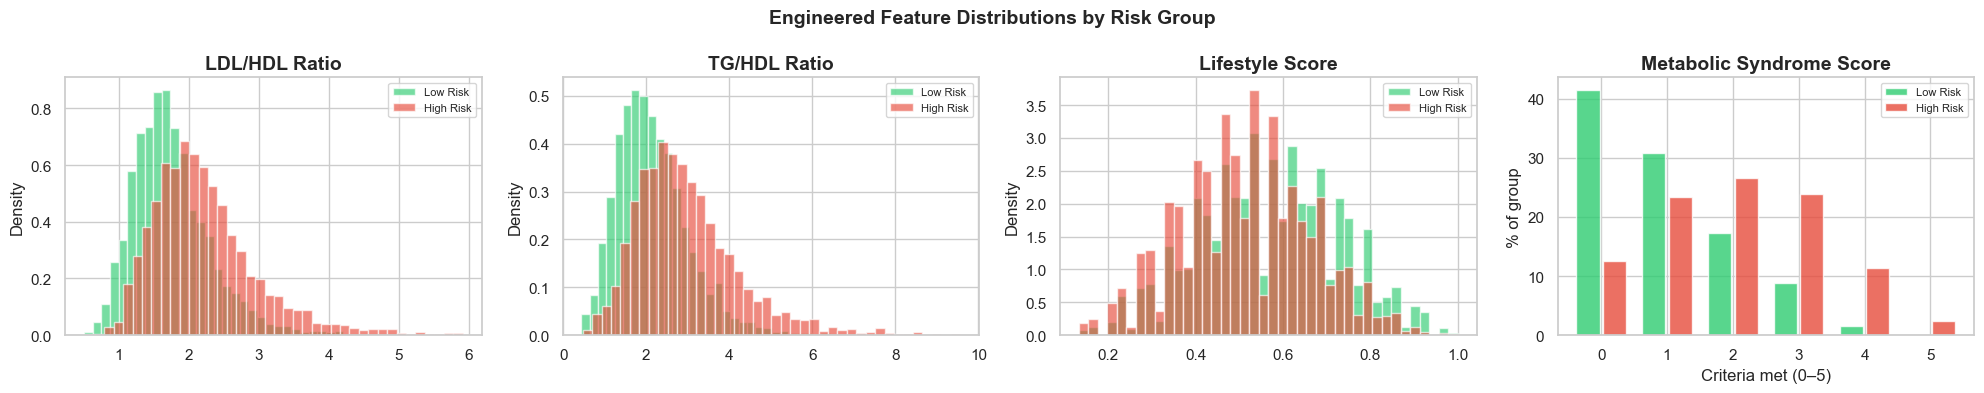

In [8]:
"""
Visual validation of the four key engineered features.
Plot density histograms for LDL/HDL ratio, TG/HDL ratio, metabolic
score, and lifestyle score to confirm that each
feature separates the two risk groups as expected.
"""

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Engineered Feature Distributions by Risk Group",
             fontsize=14, fontweight="bold")

continuous_feats = [
    ("ldl_hdl_ratio",   "LDL/HDL Ratio",    True),
    ("tg_hdl_ratio",    "TG/HDL Ratio",     True),
    ("lifestyle_score", "Lifestyle Score",  True),
]

for ax, (col, title, _) in zip(axes[:3], continuous_feats):
    for label, grp, color in [
        ("Low Risk",  df[df.cardiovascular_risk == 0], COLOR_LOW),
        ("High Risk", df[df.cardiovascular_risk == 1], COLOR_HIGH),
    ]:
        ax.hist(grp[col], bins=40, alpha=0.65, color=color,
                label=label, edgecolor="white", density=True)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

# Metabolic score as a grouped bar chart
for label, grp, color in [
    ("Low Risk",  df[df.cardiovascular_risk == 0], COLOR_LOW),
    ("High Risk", df[df.cardiovascular_risk == 1], COLOR_HIGH),
]:
    counts = grp["metabolic_score"].value_counts(normalize=True).sort_index() * 100
    axes[3].bar(
        counts.index + (0.2 if color == COLOR_HIGH else -0.2),
        counts.values,
        width=0.35, color=color, alpha=0.8,
        edgecolor="white", label=label,
    )
axes[3].set_title("Metabolic Syndrome Score", fontweight="bold")
axes[3].set_xlabel("Criteria met (0–5)")
axes[3].set_ylabel("% of group")
axes[3].legend(fontsize=8)

plt.tight_layout()
save_plot("11_engineered_features")
plt.show()

#### Train / Test Split

I apply a stratified 80/20 split to ensure the target class ratio is preserved
in both partitions. The test set represents the real-world distribution and will
not be modified at any subsequent stage.

In [9]:
"""
Stratified 80/20 train/test split.
"""

X = df.drop(columns=["cardiovascular_risk"])
y = df["cardiovascular_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train : {X_train.shape[0]:,} samples  |  Test : {X_test.shape[0]:,} samples")
print(f"High-risk ratio — Train: {y_train.mean() * 100:.1f}%  |  Test: {y_test.mean() * 100:.1f}%")

Train : 8,000 samples  |  Test : 2,000 samples
High-risk ratio — Train: 40.3%  |  Test: 40.2%


#### Feature Scaling

StandardScaler transforms each continuous variable to zero mean and unit
variance. It is fitted exclusively on the training set to prevent any
information from the test set leaking into the training distribution.

In [10]:
"""
StandardScaler fitted on the training set and applied to both partitions.
"""

# Continuous features to scale
scale_cols = [c for c in [
    "age", "height_cm", "weight_kg", "bmi", "waist_circumference_cm",
    "systolic_bp_mmhg", "diastolic_bp_mmhg", "resting_hr_bpm",
    "total_cholesterol_mg_dl", "ldl_mg_dl", "hdl_mg_dl", "triglycerides_mg_dl",
    "fasting_glucose_mg_dl", "hba1c_pct",
    "diet_quality", "sleep_hours", "stress_level",
    # engineered features
    "ldl_hdl_ratio", "tg_hdl_ratio", "pulse_pressure",
    "metabolic_score", "lifestyle_score",
    "age_x_diabetes",
    "smoking_x_htn",      # ordinal 0-2, scaled for distance-based models
] if c in X_train.columns]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# Fit ONLY on training data
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])

# Training set means and stds after scaling
check = X_train_scaled[scale_cols[:3]].agg(["mean", "std"]).round(4)
print(f"Columns scaled : {len(scale_cols)}")
print("\nScaling verification (first 3 columns — train):")
print(check.to_string())

Columns scaled : 24

Scaling verification (first 3 columns — train):
         age  height_cm  weight_kg
mean  0.0000     0.0000    -0.0000
std   1.0001     1.0001     1.0001


#### Class Balancing with SMOTE

SMOTE generates synthetic samples for the minority class by interpolating 
between existing observations. Unlike simple duplication, this introduces genuine new variation. 
It is applied only to the training set to preserve the real distribution in the test set.

In [11]:
"""
SMOTE oversampling on the training set.

I use k_neighbors=5 and report the number of synthetic
samples generated so the degree of augmentation is transparent.
The test set is untouched throughout this step.
"""

print("Before SMOTE:")
print(f"  High risk  : {y_train.sum():,}  ({y_train.mean() * 100:.1f}%)")
print(f"  Low risk   : {(y_train == 0).sum():,}  ({(y_train == 0).mean() * 100:.1f}%)")

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

synthetic_added = y_train_bal.sum() - y_train.sum()

print("\nAfter SMOTE:")
print(f"  High risk  : {y_train_bal.sum():,}  ({y_train_bal.mean() * 100:.1f}%)")
print(f"  Low risk   : {(y_train_bal == 0).sum():,}  ({(y_train_bal == 0).mean() * 100:.1f}%)")
print(f"  Synthetic samples added: +{synthetic_added:,}")

Before SMOTE:
  High risk  : 3,221  (40.3%)
  Low risk   : 4,779  (59.7%)

After SMOTE:
  High risk  : 4,779  (50.0%)
  Low risk   : 4,779  (50.0%)
  Synthetic samples added: +1,558


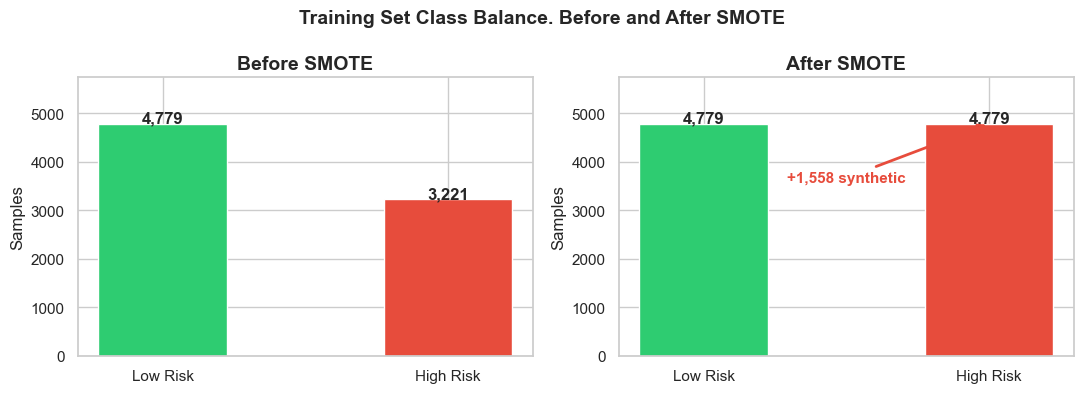

In [12]:
"""
Class balance visualisation.
"""

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Training Set Class Balance. Before and After SMOTE",
             fontsize=14, fontweight="bold")

for ax, y_data, title in [
    (axes[0], pd.Series(y_train),     "Before SMOTE"),
    (axes[1], pd.Series(y_train_bal), "After SMOTE"),
]:
    cnts = y_data.value_counts().sort_index()
    bars = ax.bar(
        ["Low Risk", "High Risk"], cnts.values,
        color=[COLOR_LOW, COLOR_HIGH], edgecolor="white", width=0.45,
    )
    for bar, v in zip(bars, cnts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, v + 20,
            f"{v:,}", ha="center", fontsize=12, fontweight="bold",
        )
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Samples")
    ax.set_ylim(0, pd.Series(y_train_bal).value_counts().max() * 1.20)

# Arrow annotation showing synthetic samples added
axes[1].annotate(
    f"+{synthetic_added:,} synthetic",
    xy=(1, y_train_bal.sum()),
    xytext=(0.5, y_train_bal.sum() * 0.75),
    arrowprops=dict(arrowstyle="->", color=COLOR_HIGH, lw=2),
    fontsize=11, color=COLOR_HIGH, fontweight="bold", ha="center",
)

plt.tight_layout()
save_plot("12_smote")
plt.show()

#### Feature Correlation After Engineering

I check the correlation of every feature with the target to confirm that the new indices improve discriminative signal.

In [13]:
"""
Top 15 features ranked by absolute Pearson correlation with the target.
"""

engineered = {
    "ldl_hdl_ratio", "tg_hdl_ratio", "pulse_pressure",
    "metabolic_score", "lifestyle_score", "abdominal_obesity",
    "age_x_diabetes", "smoking_x_htn",
}

train_with_target = pd.concat(
    [X_train.reset_index(drop=True), y_train.reset_index(drop=True)],
    axis=1,
)

feat_corr = (
    train_with_target.corr()["cardiovascular_risk"]
    .drop("cardiovascular_risk")
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

print("Top 15 features by Pearson r, with cardiovascular_risk:")
print("-" * 50)
for rank, (feat, val) in enumerate(feat_corr.items(), 1):
    tag = "  ★ engineered" if feat in engineered else ""
    print(f"  {rank:>2}. {feat:<30}  r = {val:.3f}{tag}")

Top 15 features by Pearson r, with cardiovascular_risk:
--------------------------------------------------
   1. metabolic_score                 r = 0.413  ★ engineered
   2. age_x_diabetes                  r = 0.407  ★ engineered
   3. diabetes                        r = 0.398
   4. cv_medication                   r = 0.366
   5. systolic_bp_mmhg                r = 0.360
   6. tg_hdl_ratio                    r = 0.355  ★ engineered
   7. hypertension                    r = 0.345
   8. ldl_hdl_ratio                   r = 0.342  ★ engineered
   9. fasting_glucose_mg_dl           r = 0.335
  10. hdl_mg_dl                       r = 0.302
  11. smoking_x_htn                   r = 0.292  ★ engineered
  12. triglycerides_mg_dl             r = 0.286
  13. diastolic_bp_mmhg               r = 0.286
  14. waist_circumference_cm          r = 0.281
  15. hba1c_pct                       r = 0.281


#### Export Processed Datasets

In [14]:
"""
Export three CSV files to the processed directory.
"""

feature_cols = list(X_train_scaled.columns)

# Balanced training set
train_balanced = pd.concat(
    [
        pd.DataFrame(X_train_bal, columns=feature_cols),
        pd.Series(y_train_bal, name="cardiovascular_risk"),
    ],
    axis=1,
)

# Final test set
test_final = pd.concat(
    [
        X_test_scaled.reset_index(drop=True),
        y_test.reset_index(drop=True),
    ],
    axis=1,
)

# Original training set for reference comparisons 
train_original = pd.concat(
    [
        X_train_scaled.reset_index(drop=True),
        y_train.reset_index(drop=True),
    ],
    axis=1,
)

train_balanced.to_csv(PROCESSED_DIR / "train_balanced.csv", index=False)
test_final.to_csv(    PROCESSED_DIR / "test.csv",           index=False)
train_original.to_csv(PROCESSED_DIR / "train_original.csv", index=False)

print("Exported files:")
print(f"  train_balanced.csv  — {train_balanced.shape}  | "
      f"high risk: {train_balanced['cardiovascular_risk'].mean() * 100:.1f}%")
print(f"  test.csv            — {test_final.shape}  | "
      f"high risk: {test_final['cardiovascular_risk'].mean() * 100:.1f}%")
print(f"  train_original.csv  — {train_original.shape}  | "
      f"high risk: {train_original['cardiovascular_risk'].mean() * 100:.1f}%")

Exported files:
  train_balanced.csv  — (9558, 38)  | high risk: 50.0%
  test.csv            — (2000, 38)  | high risk: 40.2%
  train_original.csv  — (8000, 38)  | high risk: 40.3%
